In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.8.0+cu128
CUDA available: True
Using device: cuda
GPU: NVIDIA A100-PCIE-40GB


In [2]:
DATASET_PATH = "/fs/ess/PAS2699/osc_summer_camp_2026/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Valid exists:", os.path.exists(VALID_DIR))

print("Train classes:", len(os.listdir(TRAIN_DIR)))
print("Valid classes:", len(os.listdir(VALID_DIR)))

Train exists: True
Valid exists: True
Train classes: 38
Valid classes: 38


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transform)
valid_dataset = ImageFolder(root=VALID_DIR, transform=val_transform)

NUM_CLASSES = len(train_dataset.classes)

print("Number of classes:", NUM_CLASSES)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

print("\nFirst 5 classes:")
for i, cls in enumerate(train_dataset.classes[:5]):
    print(f"{i}: {cls}")

Number of classes: 38
Training samples: 70295
Validation samples: 17572

First 5 classes:
0: Apple___Apple_scab
1: Apple___Black_rot
2: Apple___Cedar_apple_rust
3: Apple___healthy
4: Blueberry___healthy


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=1,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train batches: 2197
Validation batches: 550


In [6]:
print("Loading pretrained ResNet18...")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print("Original final layer:")
print(model.fc)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

print("\nNew final layer:")
print(model.fc)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nModel ready.")
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Loading pretrained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /users/PAS2699/habg21/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Original final layer:
Linear(in_features=512, out_features=1000, bias=True)

New final layer:
Linear(in_features=512, out_features=38, bias=True)

Model ready.
Total parameters: 11,196,006
Trainable parameters: 11,196,006


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam, lr=0.001")
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: Adam, lr=0.001
Scheduler: ReduceLROnPlateau


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            running_acc = 100 * correct / total
            print(
                f"Batch {batch_idx + 1}/{len(loader)} "
                f"| Loss: {loss.item():.4f} "
                f"| Running Acc: {running_acc:.2f}%"
            )

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

In [9]:
NUM_EPOCHS = 1

train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

print(f"Starting training for {NUM_EPOCHS} epoch(s)")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 50)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nTrain | Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_plantdisease_part2_best.pth")
        print(f"New best model saved. Val Acc: {best_val_acc:.2f}%")

    print("=" * 70)

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

Starting training for 1 epoch(s)

Epoch 1/1
--------------------------------------------------
Batch 50/2197 | Loss: 1.1679 | Running Acc: 62.81%
Batch 100/2197 | Loss: 0.4255 | Running Acc: 72.09%
Batch 150/2197 | Loss: 0.3180 | Running Acc: 76.42%
Batch 200/2197 | Loss: 0.4031 | Running Acc: 78.64%
Batch 250/2197 | Loss: 0.4622 | Running Acc: 80.59%
Batch 300/2197 | Loss: 0.2086 | Running Acc: 82.05%
Batch 350/2197 | Loss: 0.1625 | Running Acc: 83.14%
Batch 400/2197 | Loss: 0.3366 | Running Acc: 83.87%
Batch 450/2197 | Loss: 0.3051 | Running Acc: 84.90%
Batch 500/2197 | Loss: 0.0949 | Running Acc: 85.78%
Batch 550/2197 | Loss: 0.2877 | Running Acc: 86.33%
Batch 600/2197 | Loss: 0.2480 | Running Acc: 86.83%
Batch 650/2197 | Loss: 0.2139 | Running Acc: 87.19%
Batch 700/2197 | Loss: 0.1860 | Running Acc: 87.48%
Batch 750/2197 | Loss: 0.4786 | Running Acc: 87.88%
Batch 800/2197 | Loss: 0.0798 | Running Acc: 88.25%
Batch 850/2197 | Loss: 0.0439 | Running Acc: 88.66%
Batch 900/2197 | Loss:

In [10]:
print("Model saved:", os.path.exists("resnet18_plantdisease_part2_best.pth"))

Model saved: True


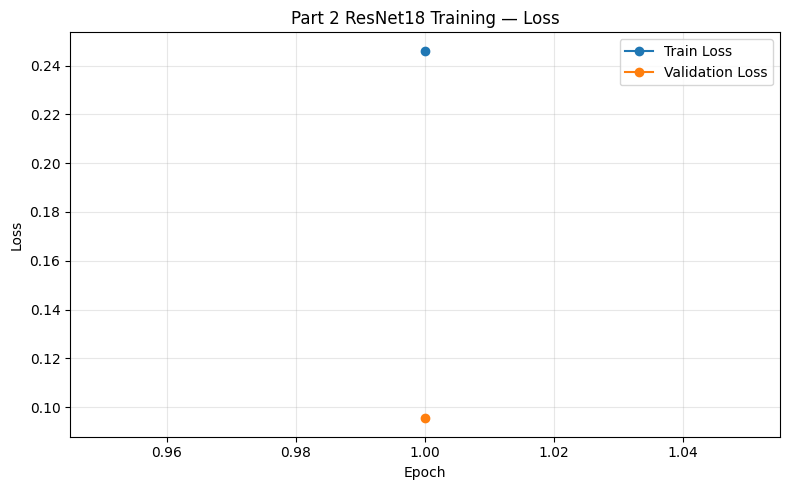

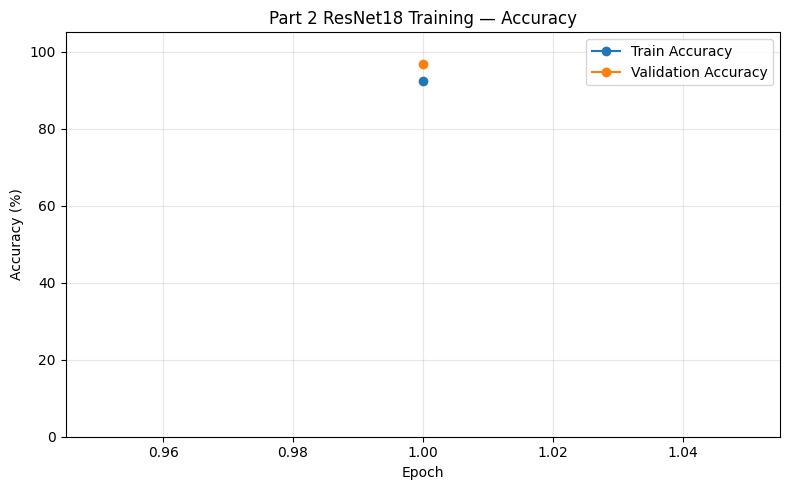

Saved plots:
part2_loss_curve.png
part2_accuracy_curve.png


In [11]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 2 ResNet18 Training — Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("part2_loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accs, marker="o", label="Train Accuracy")
plt.plot(epochs, val_accs, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Part 2 ResNet18 Training — Accuracy")
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("part2_accuracy_curve.png", dpi=150)
plt.show()

print("Saved plots:")
print("part2_loss_curve.png")
print("part2_accuracy_curve.png")